In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# 1

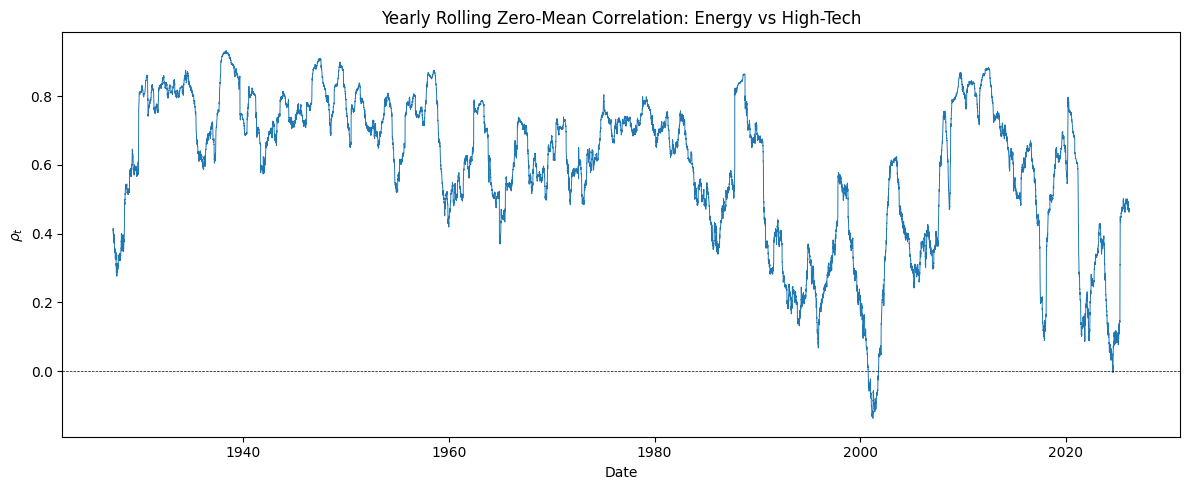

In [3]:
df = pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

r_e = df['Enrgy'].values
r_ht = df['HiTec'].values

window = 252
n = len(r_e)
rho = np.full(n, np.nan)

for t in range(window, n):
    re_w = r_e[t - window:t]
    rht_w = r_ht[t - window:t]
    cov = np.mean(re_w * rht_w)
    vol_e = np.sqrt(np.mean(re_w**2))
    vol_ht = np.sqrt(np.mean(rht_w**2))
    rho[t] = cov / (vol_e * vol_ht)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], rho, linewidth=0.7)
ax.set_xlabel('Date')
ax.set_ylabel(r'$\rho_t$')
ax.set_title('Yearly Rolling Zero-Mean Correlation: Energy vs High-Tech')
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()


In [4]:
mean_rho = np.nanmean(rho)
median_rho = np.nanmedian(rho)
q05 = np.nanquantile(rho, 0.05)
q95 = np.nanquantile(rho, 0.95)

print(f'mean: {mean_rho}, median: {median_rho}, q05: {q05}, q95: {q95}')

mean: 0.6014495772586683, median: 0.6561367093153252, q05: 0.1815636378876086, q95: 0.8605484800941082


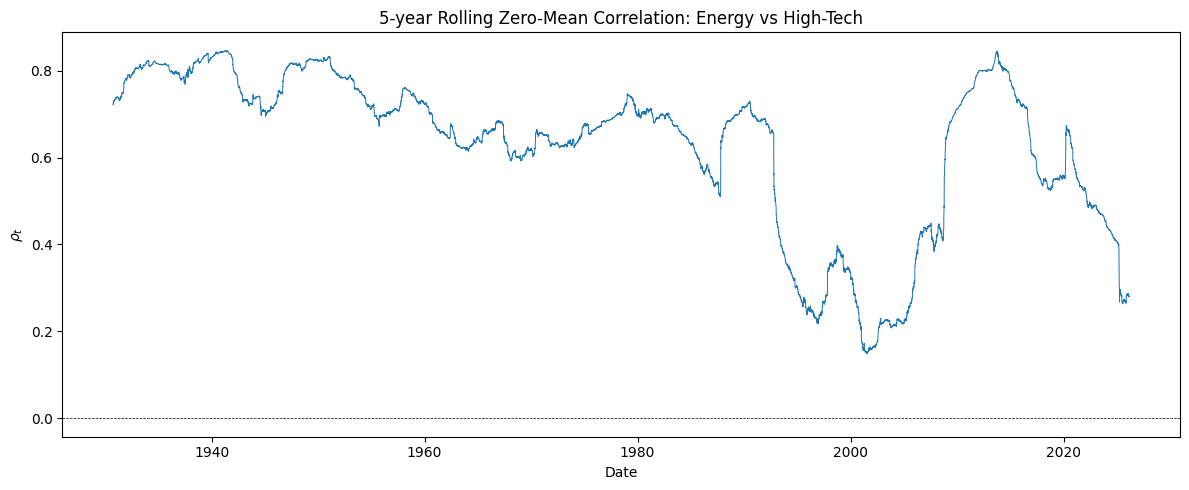

mean: 0.633566553871756, median: 0.6853455933577199, q05: 0.23618785938232195, q95: 0.8247170970742468


In [5]:
df = pd.read_csv('data.csv')
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

r_e = df['Enrgy'].values
r_ht = df['HiTec'].values

window = 252 * 5
n = len(r_e)
rho = np.full(n, np.nan)

for t in range(window, n):
    re_w = r_e[t - window:t]
    rht_w = r_ht[t - window:t]
    cov = np.mean(re_w * rht_w)
    vol_e = np.sqrt(np.mean(re_w**2))
    vol_ht = np.sqrt(np.mean(rht_w**2))
    rho[t] = cov / (vol_e * vol_ht)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['date'], rho, linewidth=0.7)
ax.set_xlabel('Date')
ax.set_ylabel(r'$\rho_t$')
ax.set_title('5-year Rolling Zero-Mean Correlation: Energy vs High-Tech')
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()

mean_rho = np.nanmean(rho)
median_rho = np.nanmedian(rho)
q05 = np.nanquantile(rho, 0.05)
q95 = np.nanquantile(rho, 0.95)

print(f'mean: {mean_rho}, median: {median_rho}, q05: {q05}, q95: {q95}')

# 2

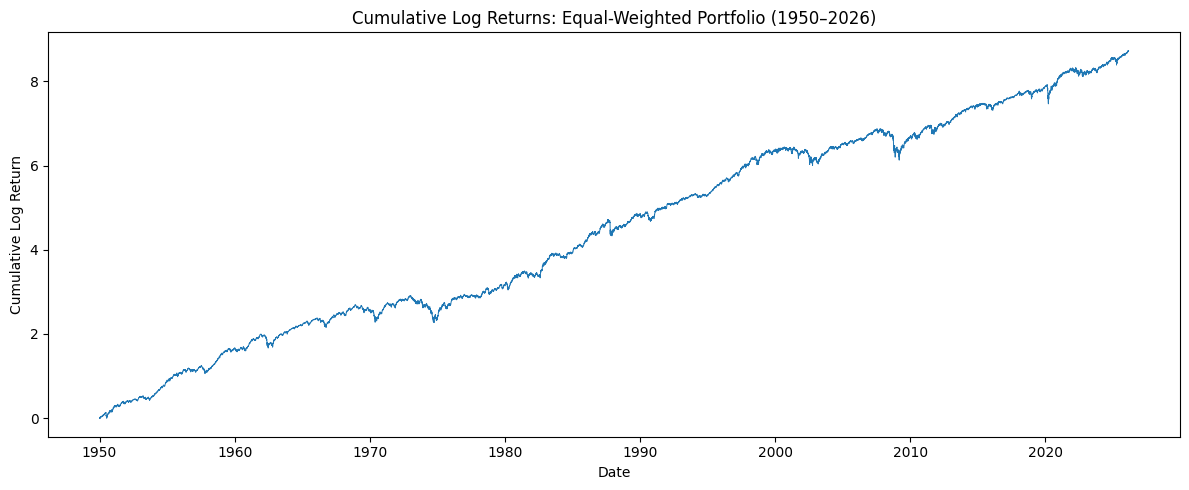

Annualized mean:  0.1250
Annualized std:   0.1455
Sharpe ratio:     0.8592


In [6]:
sectors = ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']
mask = (df['date'] >= '1950-01-01') & (df['date'] <= '2026-12-31')
df_sub = df.loc[mask].copy()

rets = df_sub[sectors].values / 100
port_ret = rets.mean(axis=1)

cum_log_ret = np.cumsum(np.log(1 + port_ret))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sub["date"].values, cum_log_ret, linewidth=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.set_title("Cumulative Log Returns: Equal-Weighted Portfolio (1950–2026)")
fig.tight_layout()
plt.show()
# Annualized mean, std, Sharpe (on simple returns, not logs)
ann_mean = port_ret.mean() * 252
ann_std = port_ret.std() * np.sqrt(252)
sharpe = ann_mean / ann_std
print(f"Annualized mean:  {ann_mean:.4f}")
print(f"Annualized std:   {ann_std:.4f}")
print(f"Sharpe ratio:     {sharpe:.4f}")


inverse-vol weights
    NoDur: 0.1282
    Durbl: 0.0723
    Manuf: 0.1042
    Enrgy: 0.0802
    HiTec: 0.0787
    Telcm: 0.1030
    Shops: 0.1058
    Hlth: 0.1028
    Utils: 0.1278
    Other: 0.0969


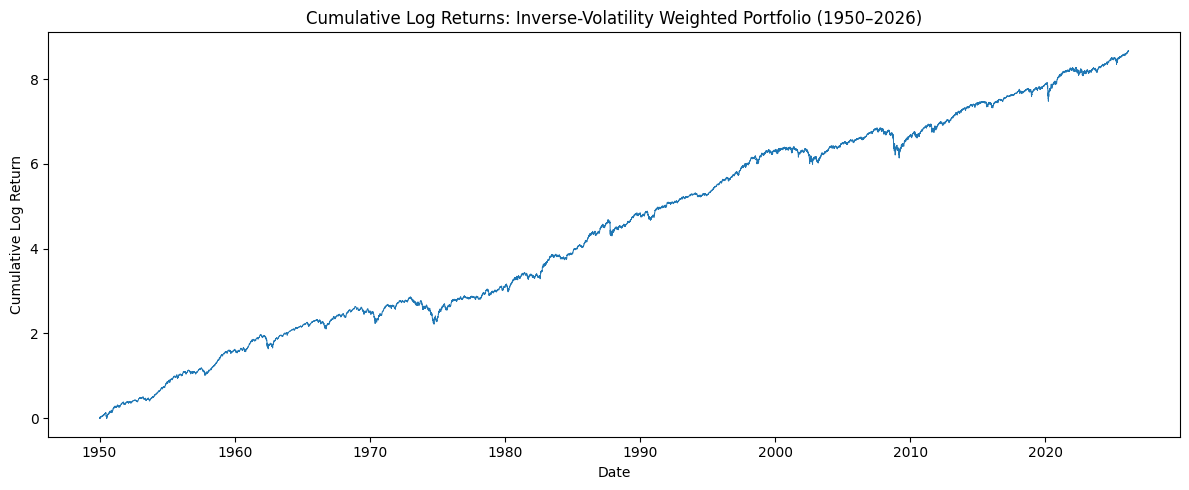

Annualized mean:  0.1236
Annualized std:   0.1411
Sharpe ratio:     0.8755


In [7]:
stds = rets.std(axis=0)

raw_weights = 1 / stds 
weights = raw_weights / raw_weights.sum()

print('inverse-vol weights')
for name, w in zip(sectors, weights):
    print(f'    {name}: {w:.4f}')

port_ret_iv = rets @ weights
cum_log_ret_iv = np.cumsum(np.log(1 + port_ret_iv))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sub["date"].values, cum_log_ret_iv, linewidth=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.set_title("Cumulative Log Returns: Inverse-Volatility Weighted Portfolio (1950–2026)")
fig.tight_layout()
plt.show()
# Annualized mean, std, Sharpe
ann_mean_iv = port_ret_iv.mean() * 252
ann_std_iv = port_ret_iv.std() * np.sqrt(252)
sharpe_iv = ann_mean_iv / ann_std_iv
print(f"Annualized mean:  {ann_mean_iv:.4f}")
print(f"Annualized std:   {ann_std_iv:.4f}")
print(f"Sharpe ratio:     {sharpe_iv:.4f}")


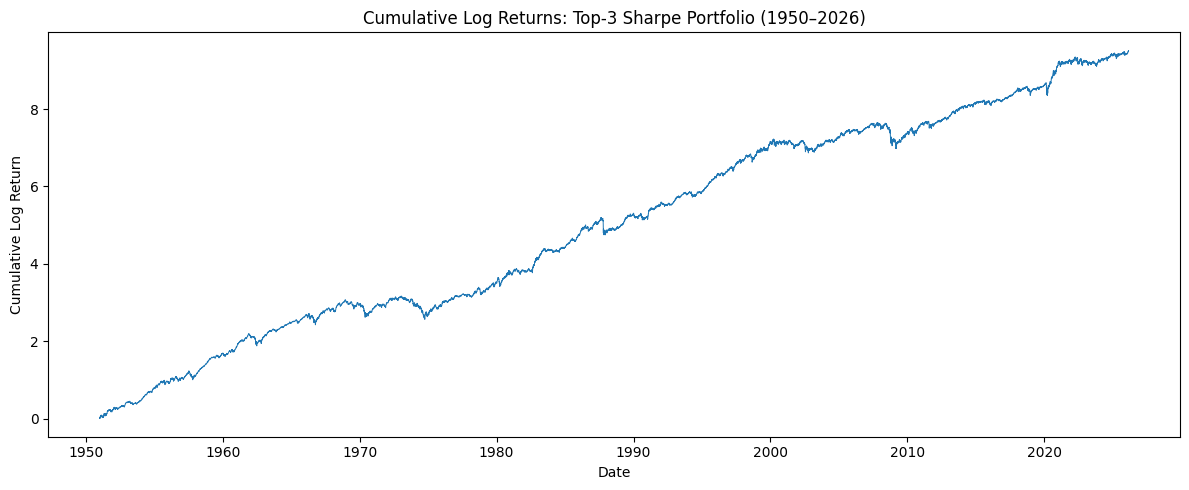

Annualized mean:  0.1377
Annualized std:   0.1502
Sharpe ratio:     0.9166


In [8]:
# Build monthly boundaries
df_sub = df_sub.copy()
df_sub["ym"] = df_sub["date"].dt.to_period("M")
months = df_sub["ym"].unique()

port_ret_top3 = np.zeros(len(df_sub))

for i, m in enumerate(months):
    # Need at least 12 months of history
    if i < 12:
        # No position in the first 12 months
        mask_m = df_sub["ym"] == m
        port_ret_top3[mask_m.values] = 0
        continue

    # Past 12 months of data
    past_months = months[i - 12:i]
    mask_past = df_sub["ym"].isin(past_months)
    past_rets = rets[mask_past.values]

    # Annualized Sharpe per sector over past 12 months
    sharpes = past_rets.mean(axis=0) / past_rets.std(axis=0) * np.sqrt(252)

    # Top 3 sectors
    top3 = np.argsort(sharpes)[-3:]

    # This month's returns: equal-weight the top 3
    mask_m = df_sub["ym"] == m
    port_ret_top3[mask_m.values] = rets[mask_m.values][:, top3].mean(axis=1)

# Cumulative log returns (skip first 12 months where we have no position)
first_valid = (df_sub["ym"] == months[12]).values.argmax()
cum_log_top3 = np.full(len(df_sub), np.nan)
cum_log_top3[first_valid:] = np.cumsum(np.log(1 + port_ret_top3[first_valid:]))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sub["date"].values, cum_log_top3, linewidth=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.set_title("Cumulative Log Returns: Top-3 Sharpe Portfolio (1950–2026)")
fig.tight_layout()
plt.show()

# Annualized stats
valid_rets = port_ret_top3[first_valid:]
ann_mean_t3 = valid_rets.mean() * 252
ann_std_t3 = valid_rets.std() * np.sqrt(252)
sharpe_t3 = ann_mean_t3 / ann_std_t3

print(f"Annualized mean:  {ann_mean_t3:.4f}")
print(f"Annualized std:   {ann_std_t3:.4f}")
print(f"Sharpe ratio:     {sharpe_t3:.4f}")

# 3

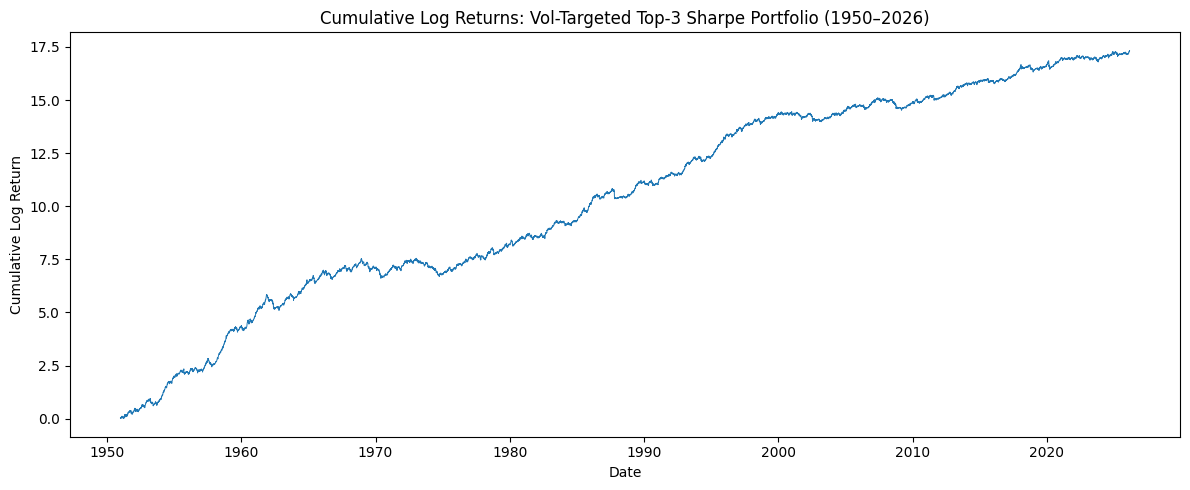

Annualized mean:  0.2538
Annualized std:   0.2164
Sharpe ratio:     1.1731


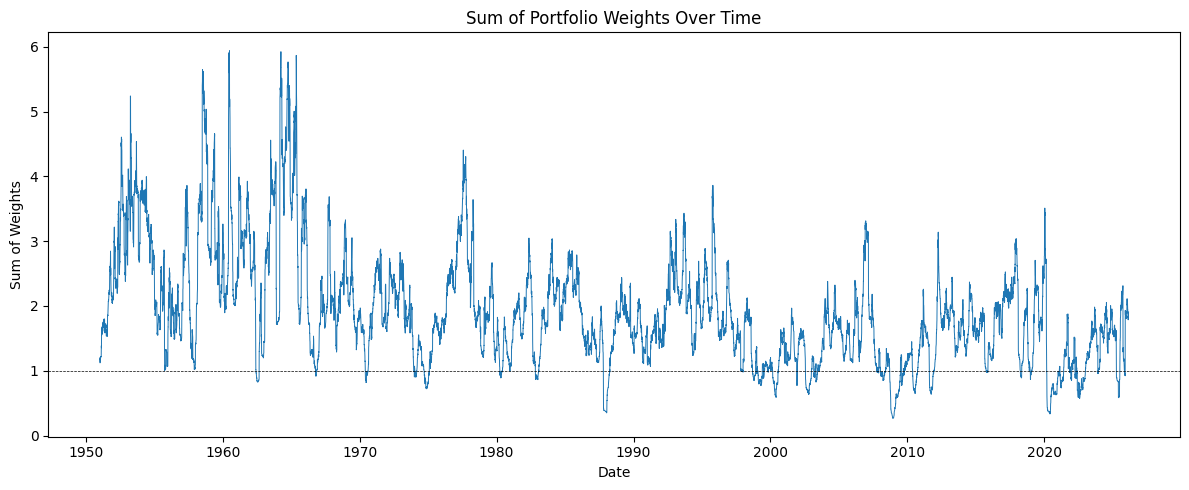

Average sum of weights: 1.9085


In [10]:
target_vol = 0.20  # 20% annualized
cov_window = 63    # 3 months

port_ret_vol_target = np.zeros(len(df_sub))
sum_weights = np.full(len(df_sub), np.nan)

for i, m in enumerate(months):
    if i < 12:
        mask_m = df_sub["ym"] == m
        port_ret_vol_target[mask_m.values] = 0
        continue

    # Same top-3 selection as Q2.3
    past_months = months[i - 12:i]
    mask_past = df_sub["ym"].isin(past_months)
    past_rets = rets[mask_past.values]
    sharpes = past_rets.mean(axis=0) / past_rets.std(axis=0) * np.sqrt(252)
    top3 = np.argsort(sharpes)[-3:]

    mask_m = df_sub["ym"] == m
    idx_m = np.where(mask_m.values)[0]

    for day_idx in idx_m:
        # Need at least 63 days of history for the covariance window
        if day_idx < cov_window:
            port_ret_vol_target[day_idx] = 0
            sum_weights[day_idx] = 0
            continue

        # Trailing 63-day returns of the 3 chosen sectors
        cov_rets = rets[day_idx - cov_window:day_idx][:, top3]

        # Daily covariance matrix
        cov_matrix = np.cov(cov_rets, rowvar=False)

        # Equal-weight vector (1/3 each, before scaling)
        w_eq = np.ones(3) / 3

        # Portfolio variance with equal weights: w' Σ w
        port_var_daily = w_eq @ cov_matrix @ w_eq

        # Annualized portfolio std
        port_std_annual = np.sqrt(port_var_daily * 252)

        # Scaling factor to hit target vol
        if port_std_annual > 0:
            scale = target_vol / port_std_annual
        else:
            scale = 0

        # Scaled weights
        w_scaled = w_eq * scale

        # Daily portfolio return
        port_ret_vol_target[day_idx] = rets[day_idx][top3] @ w_scaled
        sum_weights[day_idx] = w_scaled.sum()

# Cumulative log returns (skip first 12 months)
first_valid = (df_sub["ym"] == months[12]).values.argmax()
cum_log_vt = np.full(len(df_sub), np.nan)
cum_log_vt[first_valid:] = np.cumsum(np.log(1 + port_ret_vol_target[first_valid:]))

# Plot cumulative log returns
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sub["date"].values, cum_log_vt, linewidth=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Log Return")
ax.set_title("Cumulative Log Returns: Vol-Targeted Top-3 Sharpe Portfolio (1950–2026)")
fig.tight_layout()
plt.show()

# Annualized stats
valid_rets_vt = port_ret_vol_target[first_valid:]
ann_mean_vt = valid_rets_vt.mean() * 252
ann_std_vt = valid_rets_vt.std() * np.sqrt(252)
sharpe_vt = ann_mean_vt / ann_std_vt

print(f"Annualized mean:  {ann_mean_vt:.4f}")
print(f"Annualized std:   {ann_std_vt:.4f}")
print(f"Sharpe ratio:     {sharpe_vt:.4f}")

# Plot sum of weights over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sub["date"].values, sum_weights, linewidth=0.7)
ax.set_xlabel("Date")
ax.set_ylabel("Sum of Weights")
ax.set_title("Sum of Portfolio Weights Over Time")
ax.axhline(1, color="black", linewidth=0.5, linestyle="--")
fig.tight_layout()
plt.show()

valid_sw = sum_weights[first_valid:]
print(f"Average sum of weights: {np.nanmean(valid_sw):.4f}")

# 4

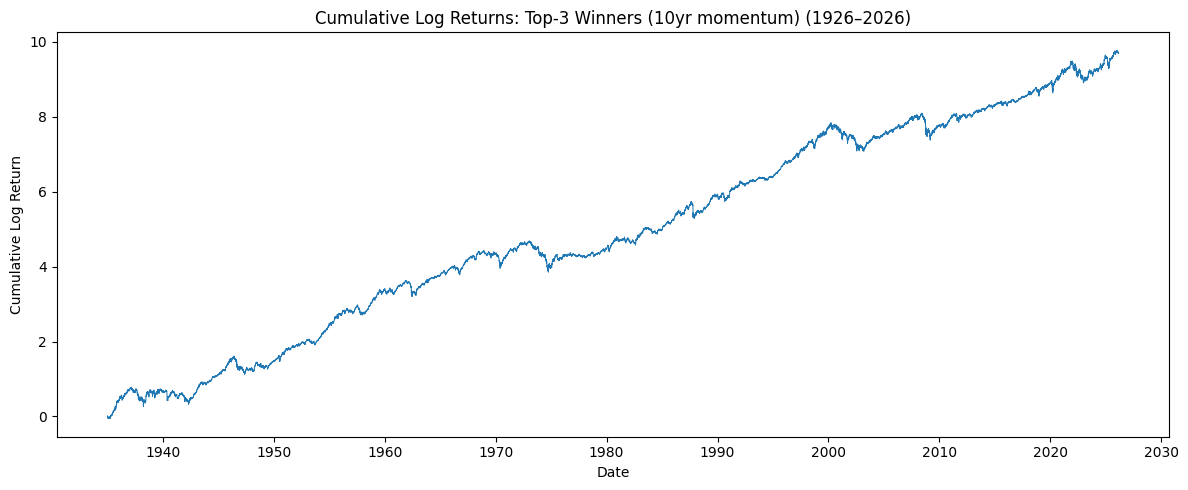

Top-3 Winners (10yr momentum)
  Annualized mean:  0.1173
  Annualized std:   0.1670
  Sharpe ratio:     0.7024


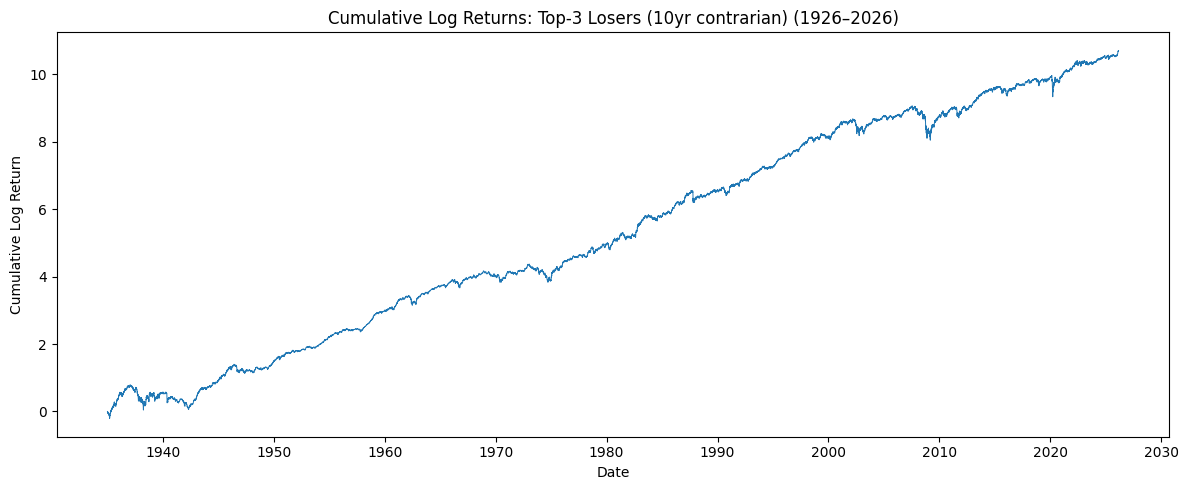

Top-3 Losers (10yr contrarian)
  Annualized mean:  0.1260
  Annualized std:   0.1544
  Sharpe ratio:     0.8160


In [11]:
# Full sample
sectors = ["NoDur", "Durbl", "Manuf", "Enrgy", "HiTec", "Telcm", "Shops", "Hlth", "Utils", "Other"]
df_full = df.copy()
rets_full = df_full[sectors].values / 100

df_full["ym"] = df_full["date"].dt.to_period("M")
months_full = df_full["ym"].unique()

lookback = 2520  # 10 years in trading days

def momentum_strategy(rets, df_sub, months, lookback, best=True, label=""):
    n = len(df_sub)
    port_ret = np.zeros(n)

    for i, m in enumerate(months):
        mask_m = df_sub["ym"] == m
        idx_m = np.where(mask_m.values)[0]

        # First day of this month — check if we have enough history
        first_day = idx_m[0]
        if first_day < lookback:
            port_ret[idx_m] = 0
            continue

        # Past 10-year returns for ranking
        past_rets = rets[first_day - lookback:first_day]
        
        # Cumulative return per sector over the lookback
        cum_rets = (1 + past_rets).prod(axis=0) - 1

        if best:
            top3 = np.argsort(cum_rets)[-3:]   # 3 best
        else:
            top3 = np.argsort(cum_rets)[:3]     # 3 worst

        port_ret[idx_m] = rets[idx_m][:, top3].mean(axis=1)

    # Cumulative log returns — start after lookback period
    first_valid_month = None
    for i, m in enumerate(months):
        mask_m = df_sub["ym"] == m
        first_day = np.where(mask_m.values)[0][0]
        if first_day >= lookback:
            first_valid_month = i
            break

    first_valid = (df_sub["ym"] == months[first_valid_month]).values.argmax()
    cum_log = np.full(n, np.nan)
    cum_log[first_valid:] = np.cumsum(np.log(1 + port_ret[first_valid:]))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_sub["date"].values, cum_log, linewidth=0.7)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Log Return")
    ax.set_title(f"Cumulative Log Returns: {label} (1926–2026)")
    fig.tight_layout()
    plt.show()

    # Stats
    valid = port_ret[first_valid:]
    am = valid.mean() * 252
    astd = valid.std() * np.sqrt(252)
    sr = am / astd
    print(f"{label}")
    print(f"  Annualized mean:  {am:.4f}")
    print(f"  Annualized std:   {astd:.4f}")
    print(f"  Sharpe ratio:     {sr:.4f}")
    return am, astd, sr

# i) Top 3 by 10-year returns (momentum / winners)
am_w, std_w, sr_w = momentum_strategy(
    rets_full, df_full, months_full, lookback,
    best=True, label="Top-3 Winners (10yr momentum)"
)

# ii) Bottom 3 by 10-year returns (losers / contrarian)
am_l, std_l, sr_l = momentum_strategy(
    rets_full, df_full, months_full, lookback,
    best=False, label="Top-3 Losers (10yr contrarian)"
)